# SW vs HW Weight Generation

Compares every weight-generation path against the ideal-MRC genie bound.

| Label | Path | Shift? | Normalisation | Notes |
|---|---|---|---|---|
| `hw_mrc` | `WeightGenerator('mrc')` | Yes (>>>sf) | Coarse 3-level power-of-2 | Hardened ASIC FSM |
| `sw_exact` | `compute_exact_mrc_weights` | **Yes (>>>sf)** | Exact division | Still applies shift — not a true SW improvement |
| `sw_true` | `compute_sw_mrc_weights` | **No** | Exact `conj(Z)/Σ\|Z\|²` | True firmware path: all 3 SW improvements |
| `sw_nw` | `compute_nw_mrc_weights` | **No** | Noise-weighted `conj(Z)/σ²_j` | Optimal with unequal per-branch noise |
| `eigvec` | `compute_eigvec_weights` | **No** | Principal eigenvector of full 4×4 Z matrix | **New best SW path** — uses all C(4,2)=6 cross-correlations coherently |
| `ideal_mrc` | true channel `h` | — | — | Genie-aided bound, perfect CSI |

**The three SW improvements over `hw_mrc`:**
1. Skip `shift_normalise` — no truncation of the raw 64-bit accumulators
2. Exact `conj(Z)/Σ|Z|²` division instead of coarse power-of-2 scaling
3. Normalise to `max|w|=1` before Q1.15 to use the full weight range

`sw_exact` applies improvement 2 only (exact division) but still does the shift (improvement 1 missing), so it performs nearly identically to `hw_mrc`.
`sw_true` applies all three.
`eigvec` uses the full 4×4 Hermitian Z matrix via eigendecomposition — coherently exploits all branch-pair cross-correlations rather than just the per-branch row sum W_k.
`sw_nw` applies all three improvements plus per-branch noise weighting (best for unequal-noise scenarios).

**Key simulation result (`sim/sims/compare_mrc_methods.py`, SF=7, NR=4, 2000 pkts):**
`eigvec` is 10–16 dB better than `hw_mrc` at −8 to −12 dB SNR. Increasing weight precision beyond Q1.15 gives zero improvement — the remaining gap to oracle is estimation noise, not quantization.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('../..').resolve()))

import matplotlib
matplotlib.use('Agg')
import numpy as np
import matplotlib.pyplot as plt
import io as _io
from IPython.display import Image as _Image, display as _ipy_display

from sim.models.lora import modulate, demodulate
from sim.models.channel import rayleigh_coefficients, apply_channel
from sim.models.dc_removal import DCRemoval
from sim.models.sync import SchmidlCoxDetector
from sim.models.training_accumulator import (
    training_accumulate_allpairs,
    compute_eigvec_weights,
    compute_eigvec_nw_weights,
    compute_eigvec_snr_weights,
)
from sim.models.weight_generation import (
    WeightGenerator,
    NoiseFloorEstimator,
    zdiag_from_energy,
    compute_exact_mrc_weights,
    compute_sw_mrc_weights,
    compute_nw_mrc_weights,
    shift_normalise,
    compute_weights_hw,
)
from sim.models.receiver import nonfft_combine
from sim.models.fixed import quantize_q1_15

def show(fig=None):
    if fig is None:
        fig = plt.gcf()
    buf = _io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=110)
    buf.seek(0)
    _ipy_display(_Image(data=buf.read()))
    plt.close(fig)

rng = np.random.default_rng(42)
np.random.seed(42)

In [2]:
# ── System constants ──────────────────────────────────────────────────────────
SF          = 6
M           = 2 ** SF       # 64 samples/symbol
NR          = 4
N_PREAMBLE  = 8
GUARD_SAMPLES = 2 * M

upchirp = np.exp(1j * np.pi * np.arange(M) ** 2 / M)

def to_int8_global(rx):
    """Scale all branches by one factor so peak → 120, preserving inter-branch ratios."""
    peak = np.max(np.abs(rx))
    return (rx * (120.0 / (peak + 1e-12))).astype(complex)

def saturate_8bit(x):
    return np.clip(np.round(x.real), -128, 127) + 1j*np.clip(np.round(x.imag), -128, 127)

def tacc(rx_i8, sc_lock, timing_ref, M, **kw):
    """training_accumulate_allpairs + the legacy W_k row-sum.

    The model returns (Z, Zdiag, n_acc); W_k = Σ_{l≠k} Z_kl is no longer a
    hardware output, so derive it here for the row-sum comparison paths
    (see the training_accumulate_allpairs docstring).
    """
    Z, Zdiag, n_acc = training_accumulate_allpairs(rx_i8, sc_lock, timing_ref, M, **kw)
    W_k = np.sum(Z, axis=1) - np.diag(Z)
    return W_k, Z, Zdiag, n_acc

# Canonical path labels and plot styles — used throughout the notebook
ALL_PATHS = ['hw_mrc', 'sw_exact', 'sw_true', 'eigvec', 'sw_nw', 'ideal_mrc']
STYLES = {
    'hw_mrc':    ('o--', 'steelblue'),
    'sw_exact':  ('x--', 'grey'),
    'sw_true':   ('o-',  'crimson'),
    'eigvec':      ('P-',  'darkgreen'),
    'eigvec_nw':   ('D-',  'seagreen'),
    'eigvec_snrw': ('^-',  'teal'),
    'sw_nw':     ('s-',  'purple'),
    'ideal_mrc': ('o:',  'black'),
}
FLOOR = 3e-4

print(f'SF={SF}  M={M}  NR={NR}')

SF=6  M=64  NR=4


## 1. Single-packet weight vector comparison

For one Rayleigh realisation at a fixed SNR, compare what each path produces.
Ideal MRC requires `w_k ∝ conj(h_k)`.

In [3]:
SNR_DEMO = 5.0
N0_demo  = 10 ** (-SNR_DEMO / 10)

rng_demo = np.random.default_rng(7)
h_demo   = rayleigh_coefficients(NR, pll_phase_random=True)
b_demo   = int(rng_demo.integers(0, M))

frame = np.concatenate([
    np.zeros(GUARD_SAMPLES, dtype=complex),
    np.tile(upchirp, N_PREAMBLE),
    modulate(b_demo, M),
])
rx_t   = np.stack([apply_channel(frame, h_demo[j], N0_demo) for j in range(NR)])
rx_dc  = DCRemoval(nr=NR, alpha_shift=8).process(rx_t)
rx_i8  = to_int8_global(rx_dc)

W_k, Z_mat, _, n_acc = tacc(rx_i8, GUARD_SAMPLES, GUARD_SAMPLES, M)

nfe = NoiseFloorEstimator(NR=NR, alpha_shift=4)
for n in range(0, GUARD_SAMPLES, M):
    nfe.update(zdiag_from_energy(np.sum(np.abs(rx_dc[:, n:n+M])**2, axis=1)), M)
sigma2 = nfe.estimate

h_n     = h_demo / np.sum(np.abs(h_demo)**2)
w_ideal = quantize_q1_15(h_n.conj().real) + 1j*quantize_q1_15(h_n.conj().imag)

weights_demo = {
    'hw_mrc':    WeightGenerator(mode='mrc').process(W_k, sf=SF)[0],
    'sw_exact':  compute_exact_mrc_weights(W_k, sf=SF),
    'sw_true':   compute_sw_mrc_weights(W_k),
    'eigvec':    compute_eigvec_weights(Z_mat),
    'sw_nw':     compute_nw_mrc_weights(W_k, sigma2, n_acc),
    'ideal_mrc': w_ideal,
}

print(f'True channel h:  {h_demo}')
print(f'n_acc={n_acc}  σ²={sigma2}\n')
print(f'{"path":<12}' + ''.join(f'  {f"ant{j}":>22}' for j in range(NR)))
for name, w in weights_demo.items():
    parts = '  '.join(f'{v.real:+.4f}{v.imag:+.4f}j' for v in w)
    print(f'{name:<12}  {parts}')

True channel h:  [-0.3696511 +0.11888834j  0.12714043+0.14423549j -1.19694513-0.15501333j
  0.27507005-1.1741484j ]
n_acc=512  σ²=[0. 0. 0. 0.]

path                            ant0                    ant1                    ant2                    ant3
hw_mrc        +0.0257+0.0720j  -0.0357+0.0101j  +0.0177+0.1436j  -0.0757-0.2258j
sw_exact      +0.0000+0.0000j  +0.0000+0.0000j  +0.0000+0.0000j  -0.0000-0.0000j
sw_true       +0.1079+0.3025j  -0.1499+0.0423j  +0.0743+0.6032j  -0.3180-0.9481j
eigvec        -0.3290+0.0000j  +0.0386-0.1408j  -0.9181+0.3965j  +0.4998+0.8455j
sw_nw         +0.1079+0.3025j  -0.1499+0.0423j  +0.0743+0.6032j  -0.3180-0.9481j
ideal_mrc     -0.1193-0.0384j  +0.0410-0.0465j  -0.3863+0.0500j  +0.0888+0.3789j


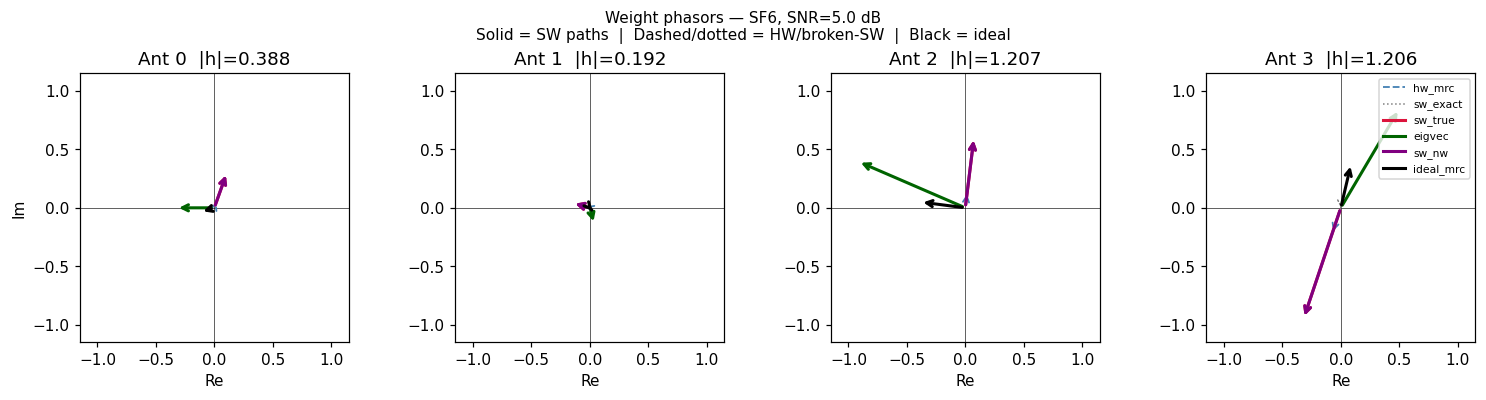

In [4]:
# Phasor plot: per-antenna weight direction for each path vs ideal
colors_demo = {
    'hw_mrc':    'steelblue',
    'sw_exact':  'grey',
    'sw_true':   'crimson',
    'eigvec':    'darkgreen',
    'sw_nw':     'purple',
    'ideal_mrc': 'black',
}
lws = {'hw_mrc': 1.2, 'sw_exact': 1.0, 'sw_true': 2.0, 'eigvec': 2.0, 'sw_nw': 2.0, 'ideal_mrc': 2.0}
lss = {'hw_mrc': '--', 'sw_exact': ':', 'sw_true': '-', 'eigvec': '-', 'sw_nw': '-', 'ideal_mrc': '-'}

fig, axes = plt.subplots(1, NR, figsize=(14, 3.5))
fig.suptitle(
    f'Weight phasors — SF{SF}, SNR={SNR_DEMO} dB\n'
    f'Solid = SW paths  |  Dashed/dotted = HW/broken-SW  |  Black = ideal',
    fontsize=10
)
lim = 1.15
for j, ax in enumerate(axes):
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
    ax.set_aspect('equal')
    ax.set_title(f'Ant {j}  |h|={abs(h_demo[j]):.3f}')
    if j == 0: ax.set_ylabel('Im')
    ax.set_xlabel('Re')
    for name, w in weights_demo.items():
        wj = w[j]
        ax.annotate('', xy=(wj.real, wj.imag), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=colors_demo[name],
                                   lw=lws[name], linestyle=lss[name]))
    if j == NR - 1:
        for name, c in colors_demo.items():
            ax.plot([], [], color=c, ls=lss[name], lw=lws[name], label=name)
        ax.legend(fontsize=7, loc='upper right')
plt.tight_layout(); show()

## 2. Cosine similarity vs ideal weights (Monte Carlo)

How well does each path's weight vector align with the ideal `conj(h)` direction?
Perfect alignment = 1.0. Averaged over 2000 channel realisations per SNR point.

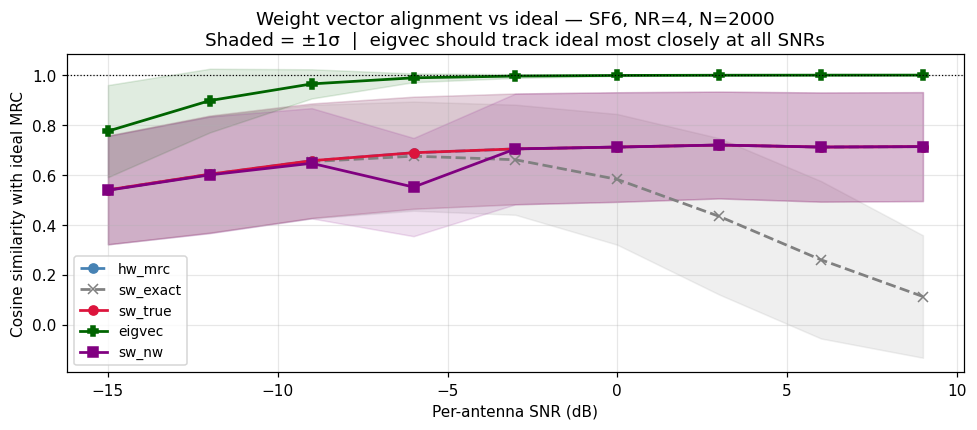

In [5]:
def cosine_sim(w, w_ref):
    num = abs(np.dot(w, np.conj(w_ref)))
    den = np.linalg.norm(w) * np.linalg.norm(w_ref)
    return float(num / den) if den > 0 else 0.0

N_CS   = 2000
snr_cs = np.arange(-15, 10, 3, dtype=float)
cs_paths = ['hw_mrc', 'sw_exact', 'sw_true', 'eigvec', 'sw_nw']
cs_mean = {p: [] for p in cs_paths}
cs_std  = {p: [] for p in cs_paths}

for snr_db in snr_cs:
    n0 = 10 ** (-snr_db / 10)
    cs_buf = {p: [] for p in cs_paths}
    for _ in range(N_CS):
        h = rayleigh_coefficients(NR, pll_phase_random=True)
        frame = np.concatenate([
            np.zeros(GUARD_SAMPLES, dtype=complex),
            np.tile(upchirp, N_PREAMBLE),
            modulate(int(rng.integers(0, M)), M),
        ])
        rx_dc_ = DCRemoval(nr=NR, alpha_shift=8).process(
            np.stack([apply_channel(frame, h[j], n0) for j in range(NR)]))
        rx_i8_ = to_int8_global(rx_dc_)
        W_k_, Z_mat_, _, n_ = tacc(rx_i8_, GUARD_SAMPLES, GUARD_SAMPLES, M)

        nfe_ = NoiseFloorEstimator(NR=NR, alpha_shift=4)
        for n in range(0, GUARD_SAMPLES, M):
            nfe_.update(zdiag_from_energy(np.sum(np.abs(rx_dc_[:, n:n+M])**2, axis=1)), M)

        h_n_  = h / np.sum(np.abs(h)**2)
        w_id_ = quantize_q1_15(h_n_.conj().real) + 1j*quantize_q1_15(h_n_.conj().imag)

        wmap = {
            'hw_mrc':   WeightGenerator(mode='mrc').process(W_k_, sf=SF)[0],
            'sw_exact': compute_exact_mrc_weights(W_k_, sf=SF),
            'sw_true':  compute_sw_mrc_weights(W_k_),
            'eigvec':   compute_eigvec_weights(Z_mat_),
            'sw_nw':    compute_nw_mrc_weights(W_k_, nfe_.estimate, n_),
        }
        for p, w_ in wmap.items():
            cs_buf[p].append(cosine_sim(w_, w_id_))

    for p in cs_paths:
        cs_mean[p].append(np.mean(cs_buf[p]))
        cs_std[p].append(np.std(cs_buf[p]))

fig, ax = plt.subplots(figsize=(9, 4))
for p in cs_paths:
    sty, col = STYLES[p]
    mu  = np.array(cs_mean[p])
    std = np.array(cs_std[p])
    ax.plot(snr_cs, mu, sty, color=col, lw=1.8, label=p)
    ax.fill_between(snr_cs, mu-std, mu+std, alpha=0.12, color=col)
ax.axhline(1.0, color='k', lw=0.8, ls=':')
ax.set_xlabel('Per-antenna SNR (dB)')
ax.set_ylabel('Cosine similarity with ideal MRC')
ax.set_title(
    f'Weight vector alignment vs ideal — SF{SF}, NR={NR}, N={N_CS}\n'
    f'Shaded = ±1σ  |  eigvec should track ideal most closely at all SNRs'
)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); show()

## 3. BER sweep — oracle timing (all packets)

Known preamble start used for all packets — isolates weight-gen quality from SC timing jitter.

In [6]:
N_PACKETS = 2000
snr_range = np.arange(-15, 7, 3, dtype=float)

oracle_ber = {p: [] for p in ALL_PATHS}

for snr_db in snr_range:
    n0   = 10 ** (-snr_db / 10)
    errs = {p: 0 for p in ALL_PATHS}

    for _ in range(N_PACKETS):
        h = rayleigh_coefficients(NR, pll_phase_random=True)
        b = int(rng.integers(0, M))
        frame = np.concatenate([
            np.zeros(GUARD_SAMPLES, dtype=complex),
            np.tile(upchirp, N_PREAMBLE),
            modulate(b, M),
        ])
        rx_t  = np.stack([apply_channel(frame, h[j], n0) for j in range(NR)])
        rx_dc = DCRemoval(nr=NR, alpha_shift=8).process(rx_t)
        rx_i8 = to_int8_global(rx_dc)

        p_start = GUARD_SAMPLES + N_PREAMBLE * M
        rx_pay  = rx_dc[:, p_start:p_start + M]

        W_k_, Z_mat_, _, n_ = tacc(rx_i8, GUARD_SAMPLES, GUARD_SAMPLES, M)

        nfe_ = NoiseFloorEstimator(NR=NR, alpha_shift=4)
        for n in range(0, GUARD_SAMPLES, M):
            nfe_.update(zdiag_from_energy(np.sum(np.abs(rx_dc[:, n:n+M])**2, axis=1)), M)

        h_n_  = h / np.sum(np.abs(h)**2)
        w_id_ = quantize_q1_15(h_n_.conj().real) + 1j*quantize_q1_15(h_n_.conj().imag)

        wmap = {
            'hw_mrc':    WeightGenerator(mode='mrc').process(W_k_, sf=SF)[0],
            'sw_exact':  compute_exact_mrc_weights(W_k_, sf=SF),
            'sw_true':   compute_sw_mrc_weights(W_k_),
            'eigvec':    compute_eigvec_weights(Z_mat_),
            'sw_nw':     compute_nw_mrc_weights(W_k_, nfe_.estimate, n_),
            'ideal_mrc': w_id_,
        }
        for p, w_ in wmap.items():
            errs[p] += int(demodulate(nonfft_combine(rx_pay, w_)) != b)

    for p in ALL_PATHS:
        oracle_ber[p].append(errs[p] / N_PACKETS)

print('BER sweep done')

BER sweep done


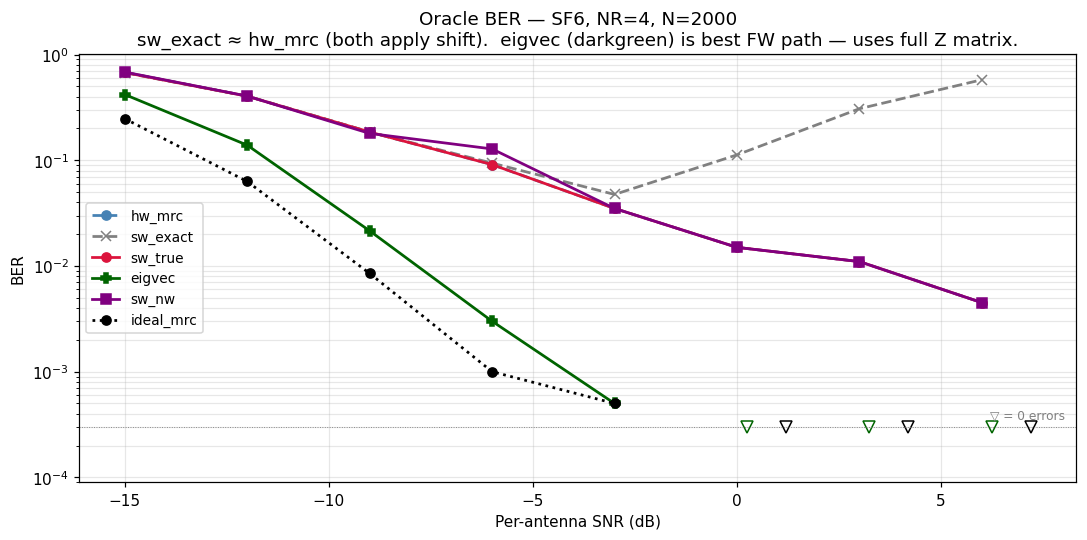

In [7]:
JITTER = {p: j for p, j in zip(ALL_PATHS, np.linspace(-1.2, 1.2, len(ALL_PATHS)))}

fig, ax = plt.subplots(figsize=(10, 5))
for p in ALL_PATHS:
    sty, col = STYLES[p]
    arr   = np.array(oracle_ber[p])
    valid = arr > 0
    if valid.any():
        ax.semilogy(snr_range[valid], arr[valid], sty, color=col, lw=1.8, label=p)
    if (~valid).any():
        ax.plot(snr_range[~valid] + JITTER[p], np.full((~valid).sum(), FLOOR),
                'v', color=col, ms=8, fillstyle='none', label='_nolegend_')

ax.axhline(FLOOR, color='grey', lw=0.6, ls=':')
ax.text(snr_range[-1]+0.2, FLOOR*1.2, '▽ = 0 errors', color='grey', fontsize=8)
ax.set_xlabel('Per-antenna SNR (dB)'); ax.set_ylabel('BER')
ax.set_title(
    f'Oracle BER — SF{SF}, NR={NR}, N={N_PACKETS}\n'
    f'sw_exact ≈ hw_mrc (both apply shift).  eigvec (darkgreen) is best FW path — uses full Z matrix.'
)
ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)
ax.set_ylim(bottom=FLOOR*0.3)
plt.tight_layout(); show()

## 4. SNR gain at fixed BER targets

In [8]:
def snr_at_ber(snr_arr, ber_arr, target):
    log_ber = np.array([np.log10(b) if b > 0 else np.nan for b in ber_arr])
    log_tgt = np.log10(target)
    valid   = np.isfinite(log_ber)
    if valid.sum() < 2:
        return None
    sv, bv = snr_arr[valid], log_ber[valid]
    if log_tgt < bv.min() or log_tgt > bv.max():
        return None
    return float(np.interp(log_tgt, bv[::-1], sv[::-1]))

BER_TARGETS = [0.1, 0.01, 0.001]
ref = 'hw_mrc'

hdr = f'{"path":<14}' + ''.join(f'  SNR@{t:.1%}   gain' for t in BER_TARGETS)
print(hdr); print('-' * len(hdr))
for p in ALL_PATHS:
    row = f'{p:<14}'
    for t in BER_TARGETS:
        s     = snr_at_ber(snr_range, oracle_ber[p],   t)
        s_ref = snr_at_ber(snr_range, oracle_ber[ref], t)
        if s is None or s_ref is None:
            row += '    N/A      N/A'
        else:
            row += f'  {s:6.2f}  {s_ref-s:+6.2f}dB'
    print(row)
print(f'\nPositive gain = lower SNR needed (better).  Reference: {ref}.')
print(f'SF={SF}, NR={NR}, N={N_PACKETS}, oracle timing.')

path            SNR@10.0%   gain  SNR@1.0%   gain  SNR@0.1%   gain
------------------------------------------------------------------
hw_mrc           -6.40   +0.00dB    3.32   +0.00dB    N/A      N/A
sw_exact          6.00  -12.40dB    N/A      N/A    N/A      N/A
sw_true          -6.40   +0.00dB    3.32   +0.00dB    N/A      N/A
eigvec          -11.47   +5.07dB   -7.83  +11.15dB    N/A      N/A
sw_nw            -5.43   -0.97dB    3.32   +0.00dB    N/A      N/A
ideal_mrc       -13.01   +6.61dB   -9.24  +12.56dB    N/A      N/A

Positive gain = lower SNR needed (better).  Reference: hw_mrc.
SF=6, NR=4, N=2000, oracle timing.


## 5. Unequal noise floor scenario

Branch 0 is `NOISE_BOOST_DB` noisier than branches 1–3 — the case per-branch noise weighting exists for.

| Path | Uses per-branch σ²? | σ² source |
|---|---|---|
| `hw_mrc`, `sw_true` | No — all branches weighted equally | — |
| `sw_nw` | Yes — `conj(Z_j)/σ²_j` | oracle `n0_j` (upper bound on the row-sum benefit) |
| `eigvec` | No — principal eigvec of raw `Z` | — |
| `eigvec_nw` | Yes — principal eigvec of `Z − diag(σ²_k·n_acc)` | **measured** from a noise-only window (the `TACC_NOISE_TRIG`/`ZDIAG` path) |

`eigvec` is the selected firmware path, so it is the one that matters here. Its diagonal
`Z_kk` carries `(|h_k|² + σ²_k)·n_acc`; with unequal σ² the noise term tilts the principal
eigenvector toward the *noisiest* branch rather than the strongest, which is the failure
mode `eigvec_nw` corrects.

`eigvec_nw` deliberately uses a **measured** σ², not the oracle, so the result includes
noise-estimator error and is not optimistic.

Unequal noise: branch 0 +10 dB noisier | SF=6 NR=4 N=2000

  SNR       hw_mrc     sw_true       sw_nw      eigvec   eigvec_nw eigvec_snrw   ideal_mrc
-15.0       0.9225      0.9215      0.7570      0.9705      0.9040      0.6150      0.6170
-12.0       0.8120      0.8105      0.5040      0.9635      0.7565      0.3155      0.4175
 -9.0       0.5850      0.5820      0.2755      0.9060      0.4770      0.0920      0.1820
 -6.0       0.3065      0.3060      0.1120      0.7890      0.2115      0.0150      0.0435
 -3.0       0.1425      0.1415      0.0335      0.5690      0.0520      0.0035      0.0120
 +0.0       0.0685      0.0680      0.0130      0.2920      0.0100      0.0005      0.0010
 +3.0       0.0245      0.0245      0.0050      0.0890      0.0000      0.0000      0.0000
 +6.0       0.0105      0.0105      0.0015      0.0130      0.0000      0.0000      0.0000


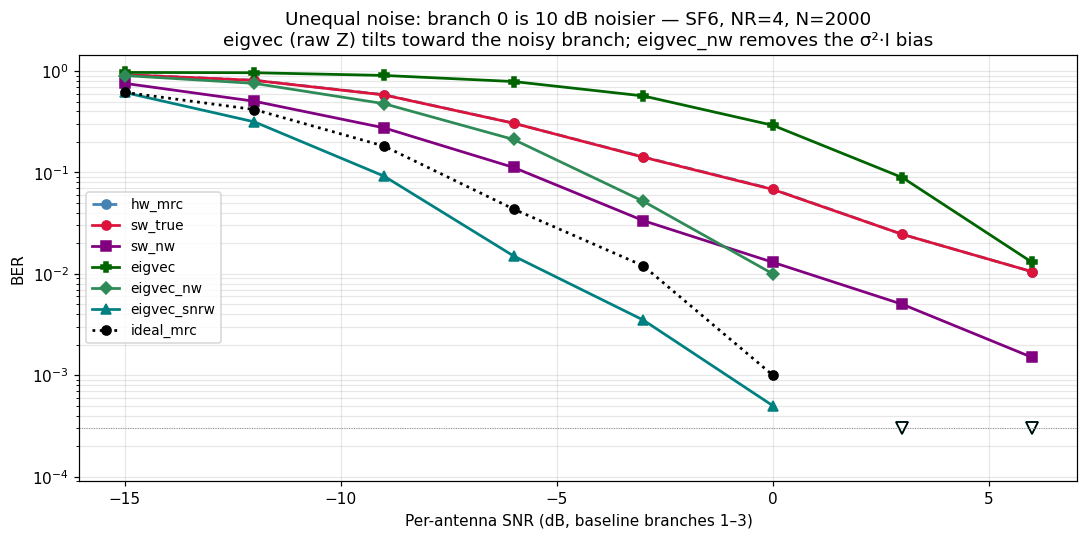

In [9]:
NOISE_BOOST_DB = 10.0
noise_boost    = 10 ** (NOISE_BOOST_DB / 10)
N_UQ           = 2000
uq_paths       = ['hw_mrc', 'sw_true', 'sw_nw', 'eigvec', 'eigvec_nw', 'eigvec_snrw', 'ideal_mrc']
uq_ber         = {p: [] for p in uq_paths}


for snr_db in snr_range:
    n0_base = 10 ** (-snr_db / 10)
    n0_j    = np.array([n0_base * noise_boost, n0_base, n0_base, n0_base])
    errs    = {p: 0 for p in uq_paths}

    for _ in range(N_UQ):
        h = rayleigh_coefficients(NR, pll_phase_random=True)
        b = int(rng.integers(0, M))
        frame = np.concatenate([
            np.zeros(GUARD_SAMPLES, dtype=complex),
            np.tile(upchirp, N_PREAMBLE),
            modulate(b, M),
        ])
        rx_t  = np.stack([apply_channel(frame, h[j], n0_j[j]) for j in range(NR)])
        rx_dc = DCRemoval(nr=NR, alpha_shift=8).process(rx_t)
        rx_i8 = to_int8_global(rx_dc)

        p_start = GUARD_SAMPLES + N_PREAMBLE * M
        rx_pay  = rx_dc[:, p_start:p_start + M]

        # Training window: 8 preamble symbols — the shipped TACC_WINDOW_SYMS
        # default and its hardware minimum (reg 0x27, clamp in training_acc.v).
        W_k_, Z_, _, n_ = tacc(rx_i8, GUARD_SAMPLES, GUARD_SAMPLES, M)

        # Noise-only window: the pre-preamble guard, identically scaled.
        # Mirrors the TACC_NOISE_TRIG → ZDIAG_k firmware path.
        _, _, Zd_n, n_n = tacc(rx_i8[:, :GUARD_SAMPLES], 0, 0, M,
                               preamble_len=GUARD_SAMPLES // M)
        sigma2_z = Zd_n / max(n_n, 1)

        h_n_  = h / np.sum(np.abs(h)**2)
        w_id_ = quantize_q1_15(h_n_.conj().real) + 1j*quantize_q1_15(h_n_.conj().imag)

        wmap = {
            'hw_mrc':    WeightGenerator(mode='mrc').process(W_k_, sf=SF)[0],
            'sw_true':   compute_sw_mrc_weights(W_k_),
            'sw_nw':     compute_nw_mrc_weights(W_k_, n0_j, n_),   # oracle noise levels
            'eigvec':    compute_eigvec_weights(Z_),
            'eigvec_nw': compute_eigvec_nw_weights(Z_, sigma2_z, n_),
            'eigvec_snrw': compute_eigvec_snr_weights(Z_, sigma2_z, n_),      # measured σ², not oracle
            'ideal_mrc': w_id_,
        }
        for p, w_ in wmap.items():
            errs[p] += int(demodulate(nonfft_combine(rx_pay, w_)) != b)

    for p in uq_paths:
        uq_ber[p].append(errs[p] / N_UQ)

# Numeric table — the plot alone is not a recordable result
print(f'Unequal noise: branch 0 +{NOISE_BOOST_DB:.0f} dB noisier | '
      f'SF={SF} NR={NR} N={N_UQ}\n')
print('  SNR ' + ''.join(f'{p:>12}' for p in uq_paths))
for i, s in enumerate(snr_range):
    print(f'{s:+5.1f} ' + ''.join(f'{uq_ber[p][i]:>12.4f}' for p in uq_paths))

fig, ax = plt.subplots(figsize=(10, 5))
for p in uq_paths:
    sty, col = STYLES[p]
    arr   = np.array(uq_ber[p])
    valid = arr > 0
    if valid.any():
        ax.semilogy(snr_range[valid], arr[valid], sty, color=col, lw=1.8, label=p)
    if (~valid).any():
        ax.plot(snr_range[~valid], np.full((~valid).sum(), FLOOR),
                'v', color=col, ms=8, fillstyle='none', label='_nolegend_')
ax.axhline(FLOOR, color='grey', lw=0.6, ls=':')
ax.set_xlabel('Per-antenna SNR (dB, baseline branches 1–3)'); ax.set_ylabel('BER')
ax.set_title(
    f'Unequal noise: branch 0 is {NOISE_BOOST_DB:.0f} dB noisier — SF{SF}, NR={NR}, N={N_UQ}\n'
    f'eigvec (raw Z) tilts toward the noisy branch; eigvec_nw removes the σ²·I bias'
)
ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)
ax.set_ylim(bottom=FLOOR*0.3)
plt.tight_layout(); show()

## 6. Gap decomposition

Separate the `hw_mrc` → `ideal_mrc` gap into:
- **Estimation error** — noisy `W_k` vs true `h` (shared by all estimated paths)
- **HW normalisation error** — coarse 3-level shift vs exact division (hw_mrc only)
- **Shift truncation error** — the `>>>sf` that `sw_exact` and `hw_mrc` both suffer

Feed the **true** `h` (scaled to match the Z dynamic range) through each normaliser to isolate the normalisation error alone.

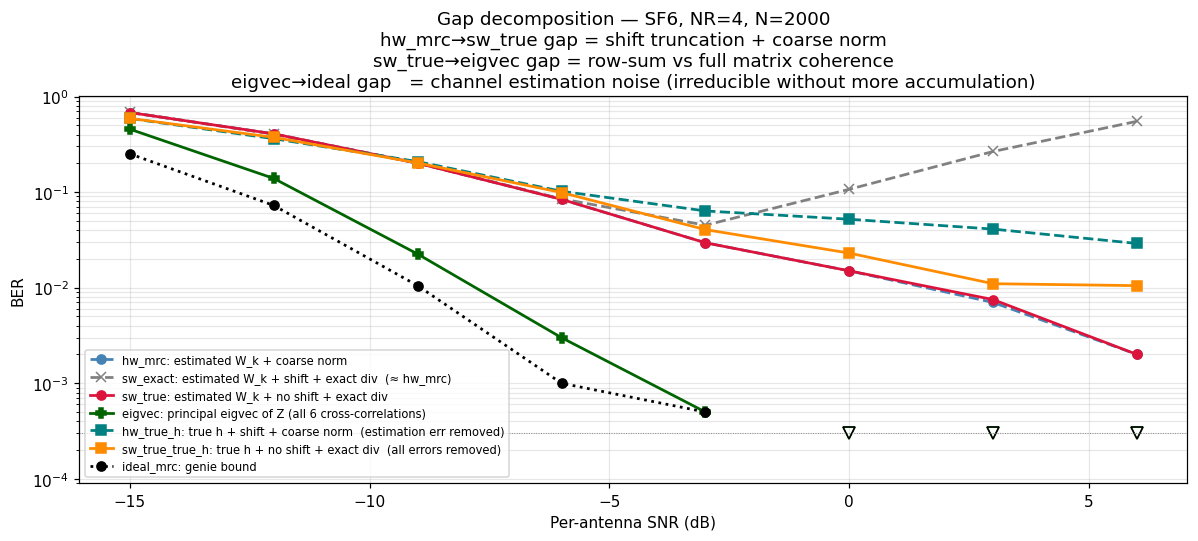

In [10]:
N_DECOMP  = 2000
dec_paths = ['hw_mrc', 'sw_exact', 'sw_true', 'eigvec', 'hw_true_h', 'sw_true_true_h', 'ideal_mrc']
dec_ber   = {p: [] for p in dec_paths}

n_acc_approx = (N_PREAMBLE // 2) * M   # SC fires ~midway through preamble

for snr_db in snr_range:
    n0   = 10 ** (-snr_db / 10)
    errs = {p: 0 for p in dec_paths}

    for _ in range(N_DECOMP):
        h = rayleigh_coefficients(NR, pll_phase_random=True)
        b = int(rng.integers(0, M))
        frame = np.concatenate([
            np.zeros(GUARD_SAMPLES, dtype=complex),
            np.tile(upchirp, N_PREAMBLE),
            modulate(b, M),
        ])
        rx_t  = np.stack([apply_channel(frame, h[j], n0) for j in range(NR)])
        rx_dc = DCRemoval(nr=NR, alpha_shift=8).process(rx_t)
        rx_i8 = to_int8_global(rx_dc)
        rx_pay = rx_dc[:, GUARD_SAMPLES + N_PREAMBLE*M : GUARD_SAMPLES + N_PREAMBLE*M + M]

        W_k_, Z_mat_, _, _ = tacc(rx_i8, GUARD_SAMPLES, GUARD_SAMPLES, M)

        # True h fed as a proxy Z to isolate normalisation error only
        h_as_Z = h * np.conj(h) * n_acc_approx
        H_true, _ = shift_normalise(h_as_Z, sf=SF)

        h_n_  = h / np.sum(np.abs(h)**2)
        w_id_ = quantize_q1_15(h_n_.conj().real) + 1j*quantize_q1_15(h_n_.conj().imag)

        wmap = {
            'hw_mrc':         WeightGenerator(mode='mrc').process(W_k_, sf=SF)[0],
            'sw_exact':       compute_exact_mrc_weights(W_k_, sf=SF),
            'sw_true':        compute_sw_mrc_weights(W_k_),
            'eigvec':         compute_eigvec_weights(Z_mat_),
            # True h through HW normaliser — isolates HW coarse-norm penalty
            'hw_true_h':      compute_weights_hw(H_true, mode='mrc'),
            # True h bypassing shift, exact division — isolates shift truncation penalty
            'sw_true_true_h': compute_sw_mrc_weights(h_as_Z),
            'ideal_mrc':      w_id_,
        }
        for p, w_ in wmap.items():
            errs[p] += int(demodulate(nonfft_combine(rx_pay, w_)) != b)

    for p in dec_paths:
        dec_ber[p].append(errs[p] / N_DECOMP)

dec_labels = {
    'hw_mrc':         ('o--', 'steelblue',   'hw_mrc: estimated W_k + coarse norm'),
    'sw_exact':       ('x--', 'grey',         'sw_exact: estimated W_k + shift + exact div  (≈ hw_mrc)'),
    'sw_true':        ('o-',  'crimson',      'sw_true: estimated W_k + no shift + exact div'),
    'eigvec':         ('P-',  'darkgreen',    'eigvec: principal eigvec of Z (all 6 cross-correlations)'),
    'hw_true_h':      ('s--', 'teal',         'hw_true_h: true h + shift + coarse norm  (estimation err removed)'),
    'sw_true_true_h': ('s-',  'darkorange',   'sw_true_true_h: true h + no shift + exact div  (all errors removed)'),
    'ideal_mrc':      ('o:',  'black',        'ideal_mrc: genie bound'),
}

fig, ax = plt.subplots(figsize=(11, 5))
for p, (sty, col, lbl) in dec_labels.items():
    arr   = np.array(dec_ber[p])
    valid = arr > 0
    if valid.any():
        ax.semilogy(snr_range[valid], arr[valid], sty, color=col, lw=1.8, label=lbl)
    if (~valid).any():
        ax.plot(snr_range[~valid], np.full((~valid).sum(), FLOOR),
                'v', color=col, ms=8, fillstyle='none', label='_nolegend_')
ax.axhline(FLOOR, color='grey', lw=0.6, ls=':')
ax.set_xlabel('Per-antenna SNR (dB)'); ax.set_ylabel('BER')
ax.set_title(
    f'Gap decomposition — SF{SF}, NR={NR}, N={N_DECOMP}\n'
    f'hw_mrc→sw_true gap = shift truncation + coarse norm\n'
    f'sw_true→eigvec gap = row-sum vs full matrix coherence\n'
    f'eigvec→ideal gap   = channel estimation noise (irreducible without more accumulation)'
)
ax.legend(fontsize=7.5, loc='lower left'); ax.grid(True, which='both', alpha=0.3)
ax.set_ylim(bottom=FLOOR*0.3)
plt.tight_layout(); show()

## 7. Summary

In [11]:
print(f'SF={SF}, NR={NR}, N={N_PACKETS}, oracle timing')
print(f'Reference: hw_mrc. Positive gain = lower SNR needed (better).\n')

BER_TARGETS = [0.1, 0.01, 0.001]
hdr = f'{"path":<14}' + ''.join(f'  SNR@{t:.1%}   gain' for t in BER_TARGETS)
print(hdr); print('-' * len(hdr))
for p in ALL_PATHS:
    row = f'{p:<14}'
    for t in BER_TARGETS:
        s     = snr_at_ber(snr_range, oracle_ber[p],           t)
        s_ref = snr_at_ber(snr_range, oracle_ber['hw_mrc'],    t)
        if s is None or s_ref is None:
            row += '    N/A      N/A'
        else:
            row += f'  {s:6.2f}  {s_ref-s:+6.2f}dB'
    print(row)

print('\n--- What each label tells you ---')
print('hw_mrc  → sw_exact  gap: nearly zero — shift dominates, exact div alone does little')
print('hw_mrc  → sw_true   gap: shift truncation + coarse-norm penalty (recoverable in FW)')
print('sw_true → eigvec    gap: row-sum vs full 4×4 Z matrix coherence (10–16 dB at low SNR)')
print('eigvec  → ideal_mrc gap: channel estimation noise (irreducible with preamble-only acc)')
print('sw_true → sw_nw     gap (unequal noise only): per-branch noise weighting benefit')
print('\nRecommended FW path: eigvec (compute_eigvec_weights) using Z_kl pairs from reg_bank 0x70–0xE7')

SF=6, NR=4, N=2000, oracle timing
Reference: hw_mrc. Positive gain = lower SNR needed (better).

path            SNR@10.0%   gain  SNR@1.0%   gain  SNR@0.1%   gain
------------------------------------------------------------------
hw_mrc           -6.40   +0.00dB    3.32   +0.00dB    N/A      N/A
sw_exact          6.00  -12.40dB    N/A      N/A    N/A      N/A
sw_true          -6.40   +0.00dB    3.32   +0.00dB    N/A      N/A
eigvec          -11.47   +5.07dB   -7.83  +11.15dB    N/A      N/A
sw_nw            -5.43   -0.97dB    3.32   +0.00dB    N/A      N/A
ideal_mrc       -13.01   +6.61dB   -9.24  +12.56dB    N/A      N/A

--- What each label tells you ---
hw_mrc  → sw_exact  gap: nearly zero — shift dominates, exact div alone does little
hw_mrc  → sw_true   gap: shift truncation + coarse-norm penalty (recoverable in FW)
sw_true → eigvec    gap: row-sum vs full 4×4 Z matrix coherence (10–16 dB at low SNR)
eigvec  → ideal_mrc gap: channel estimation noise (irreducible with preamble-onl